Generating evaluation range [0, 20] for Transfer Function parity...

          PARITY VALIDATION (Function & Gradient)

[Sigmoid]
  F(R) vs Raw Formula MSE : 2.09e-33
  Analytical df vs Finite : 1.45e-23
  fdf() internal caching  : F:0.0e+00, dF:0.0e+00
  -> SUCCESS: Sigmoid passes all parity checks.

[Compress]
  F(R) vs Raw Formula MSE : 1.87e-33
  Analytical df vs Finite : 1.35e-23
  fdf() internal caching  : F:0.0e+00, dF:0.0e+00
  -> SUCCESS: Compress passes all parity checks.

[XSigmoid]
  F(R) vs Raw Formula MSE : 4.51e-33
  Analytical df vs Finite : 4.07e-23
  fdf() internal caching  : F:0.0e+00, dF:1.5e-34
  -> SUCCESS: XSigmoid passes all parity checks.

[Gamma]
  F(R) vs Raw Formula MSE : 1.94e-32
  Analytical df vs Finite : 4.50e-23
  fdf() internal caching  : F:0.0e+00, dF:0.0e+00
  -> SUCCESS: Gamma passes all parity checks.

Saved comparison plot to g:\mp\Decoding-Au-clusters\dimredpy_vs_others\dimredpy_vs_transfer\verify_parity_transfer_plot.png


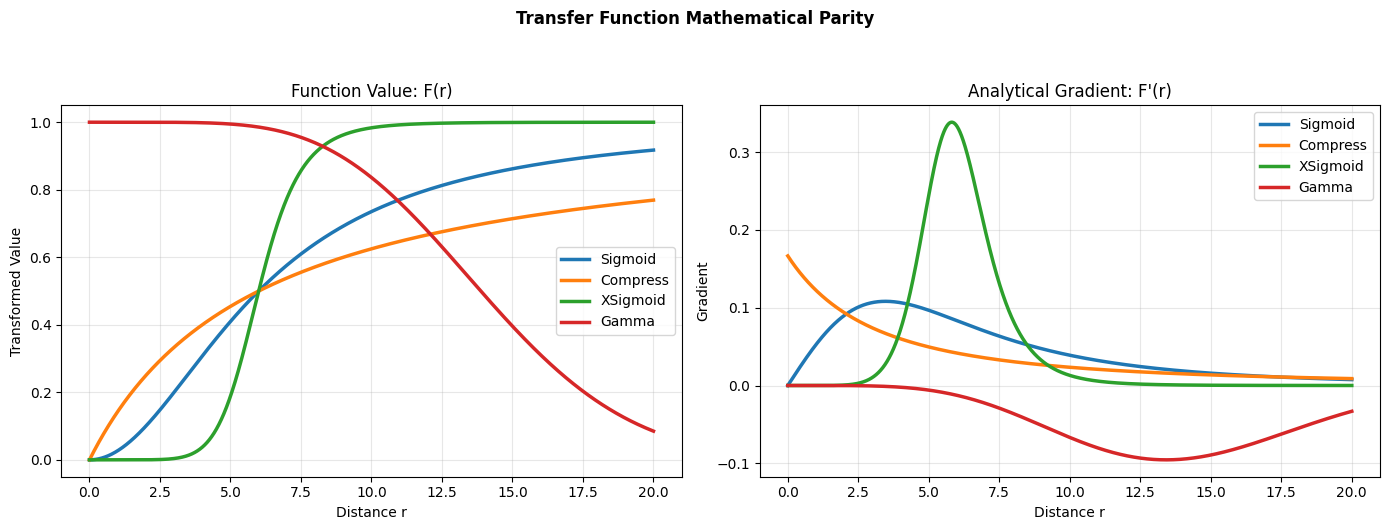

In [1]:
"""
Rigorous Verification of Transfer Function Parity and Gradients
"""

import numpy as np
import os
import sys
import matplotlib.pyplot as plt
from scipy.special import gammaincc, gamma

# Robust path detection for repo root
script_dir = os.path.dirname(os.path.abspath(__file__)) if '__file__' in locals() else os.getcwd()
repo_root = os.path.abspath(os.path.join(script_dir, "..", ".."))
if repo_root not in sys.path:
    sys.path.insert(0, repo_root)

from dimredpy.shared.transfer import Sigmoid, Compress, XSigmoid, Gamma

def numerical_gradient(f, x, eps=1e-5):
    """Compute central difference numerical gradient."""
    return (f(x + eps) - f(x - eps)) / (2.0 * eps)

# ---------------------------------------------------------------------------
# 1. Setup Data & Exact Mathematical References
# ---------------------------------------------------------------------------
print("Generating evaluation range [0, 20] for Transfer Function parity...")
x = np.linspace(0.0, 20.0, 5000)

sigma = 6.0
A = 8.0
B = 8.0
N_val = 6.0

def ref_sigmoid(r):
    return 1.0 - 1.0 / (1.0 + (r / sigma)**2)

def ref_compress(r):
    return 1.0 - 1.0 / (1.0 + (r / sigma))

def ref_xsigmoid(r):
    term = 1.0 + (2**(A/B) - 1.0) * (r / sigma)**A
    return 1.0 - term**(-B/A)

def ref_gamma(r):
    return gammaincc(N_val / 2.0, 0.5 * (r / sigma)**2)

# ---------------------------------------------------------------------------
# 2. Run DimRedPy Framework and Compare
# ---------------------------------------------------------------------------
print("\n=======================================================")
print("          PARITY VALIDATION (Function & Gradient)")
print("=======================================================")

tests = [
    ("Sigmoid", Sigmoid(sigma), ref_sigmoid),
    ("Compress", Compress(sigma), ref_compress),
    ("XSigmoid", XSigmoid(sigma, A, B), ref_xsigmoid),
    ("Gamma", Gamma(sigma, N_val), ref_gamma)
]

results = []

for name, obj, ref_func in tests:
    # Function evaluation parity
    dimred_val = obj.f(x)
    ref_val = ref_func(x)
    mse_val = np.mean((dimred_val - ref_val)**2)
    
    # Analytical vs Numerical Gradient parity
    dimred_grad = obj.df(x)
    num_grad = numerical_gradient(ref_func, x)
    # Exclude boundary edge effects for gradient MSE
    mse_grad = np.mean((dimred_grad[1:-1] - num_grad[1:-1])**2)
    
    # fdf tuple parity
    f_val, df_val = obj.fdf(x)
    mse_fdf_f = np.mean((f_val - dimred_val)**2)
    mse_fdf_df = np.mean((df_val - dimred_grad)**2)
    
    print(f"\n[{name}]")
    print(f"  F(R) vs Raw Formula MSE : {mse_val:.2e}")
    print(f"  Analytical df vs Finite : {mse_grad:.2e}")
    print(f"  fdf() internal caching  : F:{mse_fdf_f:.1e}, dF:{mse_fdf_df:.1e}")
    
    if max(mse_val, mse_grad, mse_fdf_f, mse_fdf_df) < 1e-8:
        print(f"  -> SUCCESS: {name} passes all parity checks.")
    else:
        print(f"  -> FAILURE: Divergence detected in {name}.")
        
    results.append((name, x, dimred_val, dimred_grad))

# ---------------------------------------------------------------------------
# 3. Visual Verification
# ---------------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor='white')
fig.suptitle("Transfer Function Mathematical Parity", fontweight='bold', y=1.05)

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

for i, (name, x_arr, f_arr, df_arr) in enumerate(results):
    axes[0].plot(x_arr, f_arr, label=name, color=colors[i], linewidth=2.5)
    axes[1].plot(x_arr, df_arr, label=name, color=colors[i], linewidth=2.5)

axes[0].set_title("Function Value: F(r)")
axes[0].set_xlabel("Distance r")
axes[0].set_ylabel("Transformed Value")
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].set_title("Analytical Gradient: F'(r)")
axes[1].set_xlabel("Distance r")
axes[1].set_ylabel("Gradient")
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.tight_layout()
plot_path = os.path.join(script_dir, "verify_parity_transfer_plot.png")
plt.savefig(plot_path, dpi=300, bbox_inches='tight')
print(f"\nSaved comparison plot to {plot_path}")
